In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linear_regression_ny import LinearRegression

data = np.genfromtxt("C:/Users/samue/Documents/code/Statistiska-metoder-Samuel-Airisniemi/Labb_ny/housing.csv", delimiter = ",", dtype = str, skip_header = 1)
data = np.char.strip(data)
data = data[~np.any(data == "", axis = 1)]

print("Dataset shape:", data.shape)
print("First row:", data[0])

Dataset shape: (20433, 10)
First row: ['-122.23' '37.88' '41.0' '880.0' '129.0' '322.0' '126.0' '8.3252'
 '452600.0' 'NEAR BAY']


### Grundläggande dataexploration (EDA)

Datasetet innehåller ursprungligen 20 640 observationer och 10 variabler.  
En variabel är kategorisk (ocean_proximity) och övriga är numeriska.

Variabeln total_bedrooms innehåller 207 saknade värden.  
I denna analys tas dessa rader bort före modellering, vilket ger ett slutligt stickprov på 20 433 observationer.

Detta innebär att OLS-modellerna skattas på ett komplett datamaterial utan saknade värden, men att stickprovsstorleken blir något mindre än i originaldatasetet.

In [3]:
df = pd.read_csv("C:/Users/samue/Documents/code/Statistiska-metoder-Samuel-Airisniemi/Labb_ny/housing.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### Outliers och capped values

Variabeln median_house_value är capped vid 500001 USD.  
Det innebär att alla värden över denna nivå har klippts av och inte representerar verkliga priser.

I denna analys väljer jag att behålla dessa observationer eftersom:

- De utgör en relativt liten del av datasetet  
- De fortfarande innehåller relevant information om områden med höga priser  
- Jag vill undvika att minska stickprovsstorleken i onödan  

Det viktiga är att vara medveten om denna begränsning när resultaten tolkas, eftersom cap-värdet kan innebära att de högsta bostadspriserna underskattas i modellen.

### Modellstrategi

Jag börjar med en ren numerisk modell (Model 1) för att:

- Få en baslinje för modellens förklaringsgrad  
- Identifiera kollinearitet mellan numeriska variabler  
- Se vilka variabler som är signifikanta utan kategorisk information  

Därefter utökar jag modellen med kategorivariabeln OceanProximity (Model 2).  
Slutligen bygger jag en feature‑engineered modell (Model 3) för att minska kollinearitet och öka tolkbarheten.

In [ ]:
X_num = data[:, 0:8].astype(float)
y = data[:, 8].astype(float)

feature_names_num = ["Longitude", "Latitude", "HouseAge", "TotalRooms", "TotalBedrooms", "Population", "Households", "MedInc"]

model1 = LinearRegression()
model1.fit(X_num, y, feature_names = feature_names_num)

print("MODEL 1 (Numeric only):")
model1.summary(confidence_level = 0.60)
print("R^2:", model1.r2())
print("Adjusted R^2:", model1.adjusted_r2())
print("RMSE:", model1.rmse())

print("\nVariance Inflation Factors (Model 1)")
vif_values = model1.vif(X_num)
for name, vif in zip(feature_names_num, vif_values):
    print(f"{name:25s} {vif:.2f}")

MODEL 1 (Numeric only):

Linear Regression Summary
n (samples): 20433
d (features): 8
Coefficients:
Intercept                 -3585395.747900
Longitude                 -42730.120454
Latitude                  -42509.736942
HouseAge                   1157.900307
TotalRooms                   -8.249725
TotalBedrooms               113.820707
Population                  -38.385578
Households                   47.701351
MedInc                    40297.521715
SSE: 98856034611384.437500
Sample variance (sigma^2): 4840189708.743853
Standard deviation: 69571.471946
RMSE: 69556.148396
R^2: 0.636912
Adjusted R^2: 0.636769
t-test results (individual significance):
Feature                           beta      std_err            t      p-value
Intercept                 -3585395.747900 62900.542833   -57.001030     0.000000
Longitude                 -42730.120454   717.086965   -59.588477     0.000000
Latitude                  -42509.736942   676.951557   -62.795833     0.000000
HouseAge                

### Tolkning av Model 1

Model 1 fungerar som en basmodell med enbart numeriska variabler. Den ger en relativt hög förklaringsgrad, men VIF-värdena visar att flera av de storleksrelaterade variablerna lider av stark multikollinearitet. F-testet visar att modellen som helhet är statistiskt signifikant, vilket innebär att minst en av förklaringsvariablerna bidrar till att förklara variationen i responsvariabeln.

Pearson correlation matrix:
[[ 1.    -0.925 -0.109  0.045  0.07   0.1    0.057 -0.016]
 [-0.925  1.     0.012 -0.037 -0.067 -0.109 -0.072 -0.08 ]
 [-0.109  0.012  1.    -0.361 -0.32  -0.296 -0.303 -0.118]
 [ 0.045 -0.037 -0.361  1.     0.93   0.857  0.919  0.198]
 [ 0.07  -0.067 -0.32   0.93   1.     0.878  0.98  -0.008]
 [ 0.1   -0.109 -0.296  0.857  0.878  1.     0.907  0.005]
 [ 0.057 -0.072 -0.303  0.919  0.98   0.907  1.     0.013]
 [-0.016 -0.08  -0.118  0.198 -0.008  0.005  0.013  1.   ]]


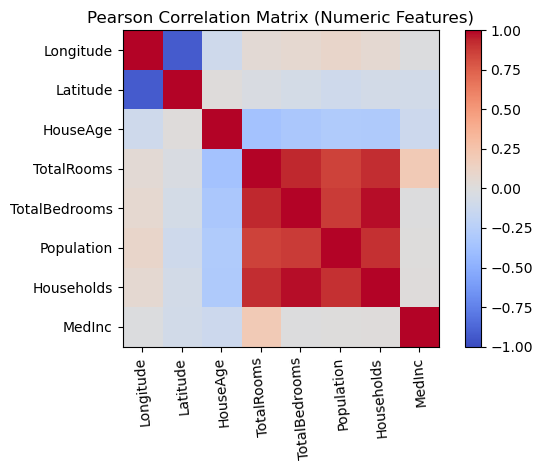

In [7]:
np.set_printoptions(precision = 3, suppress = True)
pearson = model1.pearson_matrix(X_num)

print("Pearson correlation matrix:")
print(pearson)

plt.imshow(pearson, cmap = "coolwarm", vmin = -1, vmax = 1)
plt.colorbar()
plt.title("Pearson Correlation Matrix (Numeric Features)")
plt.xticks(range(len(feature_names_num)), feature_names_num, rotation = 95)
plt.yticks(range(len(feature_names_num)), feature_names_num)
plt.tight_layout()
plt.show()

### Kollinearitet

Pearson-korrelationen mellan variablerna visar att flera av de numeriska variablerna är starkt korrelerade, särskilt TotalRooms, TotalBedrooms, Population och Households. Dessa variabler beskriver i stor utsträckning samma underliggande egenskaper hos bostadsområdena. Detta skapar multikollinearitet i regressionsmodellen.

Multikollinearitet påverkar normalt inte modellens prediktiva förmåga lika mycket, men den kan göra de individuella koefficienterna instabila och svårare att tolka. Detta beror på att variablerna delar förklaringsinformation och därför konkurrerar om samma förklaringskraft i modellen.

VIF-analysen bekräftar detta. Särskilt TotalBedrooms och Households har mycket höga VIF-värden, vilket indikerar stark multikollinearitet. När kollineariteten är hög blir standardfelen större och de individuella t-testerna mindre stabila, vilket gör att koefficienterna bör tolkas med försiktighet.

### Är alla parametrar lämpliga att ha med?

Alla parametrar som är statistiskt signifikanta är inte automatiskt lämpliga att ha med i modellen.

Eftersom stickprovet är mycket stort kan många parametrar bli statistiskt signifikanta även när de beskriver liknande information. Signifikans i sig är därför inte tillräckligt för att avgöra om en parameter borde behållas i modellen.

Detta innebär att vissa av de absoluta storleksvariablerna inte är optimala att inkludera samtidigt i en regressionsmodell om målet är statistisk tolkning. När variabler beskriver nästan samma information kan deras individuella koefficienter bli instabila och svåra att tolka isolerat.

I den första modellen inkluderas flera variabler som är starkt korrelerade med varandra. Detta gör att modellen innehåller viss redundans. Även om koefficienterna kan vara signifikanta blir deras tolkning svårare eftersom förändringar i en variabel ofta sammanfaller med förändringar i en annan. I den tredje modellen ersätts därför flera absoluta variabler med kvotvariabler som: RoomsPerHousehold, BedroomsPerRoom, PopulationPerHousehold. Dessa variabler fångar liknande information men minskar redundansen mellan variablerna och ger därför en modell som är lättare att tolka. Det gäller även vissa kategoriska parametrar. Exempelvis har kategorin ISLAND mycket få observationer i datamaterialet, vilket gör att dess koefficient bör tolkas försiktigt även om den blir statistiskt signifikant. I Model 1 ligger VIF-värdena särskilt högt för TotalBedrooms och Households, vilket tyder på stark multikollinearitet och gör de individuella koefficienterna svårare att tolka isolerat.

In [ ]:
feature_names_full = feature_names_num + ["OceanProximity"]

X_raw = np.column_stack((data[:, :8], data[:, 9]))
categorical_cols = [8]

model2 = LinearRegression()
X_encoded, new_names = model2.one_hot_encode(X_raw, categorical_cols = categorical_cols, feature_names = feature_names_full, drop_first = True)

model2.fit(X_encoded, y, feature_names = new_names)

print("MODEL 2 (Numeric + One-Hot Encoded Categorical):")
model2.summary(confidence_level = 0.60)

print("R^2:", model2.r2())
print("Adjusted R^2:", model2.adjusted_r2())
print("RMSE:", model2.rmse())

print("\nVariance Inflation Factors (Model 2)")
vif_values = model2.vif(X_encoded)
for name, vif in zip(new_names, vif_values):
    print(f"{name:25s} {vif:.2f}")

MODEL 2 (Numeric + One-Hot Encoded Categorical):

Linear Regression Summary
n (samples): 20433
d (features): 12
Coefficients:
Intercept                 -2269954.116141
Longitude                 -26812.989282
Latitude                  -25482.184831
HouseAge                   1072.520042
TotalRooms                   -6.193264
TotalBedrooms               100.556290
Population                  -37.969083
Households                   49.617326
MedInc                    39259.572876
OceanProximity_INLAND     -39284.300195
OceanProximity_ISLAND     152901.941119
OceanProximity_NEAR BAY   -3954.051625
OceanProximity_NEAR OCEAN  4278.134324
SSE: 96255324900327.500000
Sample variance (sigma^2): 4713776929.496940
Standard deviation: 68656.951065
RMSE: 68635.106931
R^2: 0.646464
Adjusted R^2: 0.646256
t-test results (individual significance):
Feature                           beta      std_err            t      p-value
Intercept                 -2269954.116141 88013.881732   -25.790865     0.00000

### Tolkning av Model 2

I Model 2 används one-hot-kodning av ocean_proximity med en referenskategori som utelämnas för att undvika perfekt multikollinearitet. Koefficienterna för de kvarvarande kategorierna ska därför tolkas relativt referenskategorin. Referenskategorin i modellen är <1H OCEAN, vilket innebär att koefficienterna för de övriga kategorierna visar skillnaden i pris relativt denna kategori.

In [ ]:
rooms_per_household = X_num[:, 3] / X_num[:, 6]
bedrooms_per_room = X_num[:, 4] / X_num[:, 3]
population_per_household = X_num[:, 5] / X_num[:, 6]

lon = X_num[:, 0]
lat = X_num[:, 1]
lon0 = np.mean(lon)
lat0 = np.mean(lat)

distance_to_centroid = np.sqrt((lon - lon0)**2 + (lat - lat0)**2)

X_fe = np.column_stack([lon, lat, X_num[:, 2], X_num[:, 7], rooms_per_household, bedrooms_per_room, population_per_household, distance_to_centroid])

feature_names_fe = ["Longitude", "Latitude", "HouseAge", "MedInc", "RoomsPerHousehold", "BedroomsPerRoom", "PopulationPerHousehold", "DistanceToCentroid"]

model3 = LinearRegression()
model3.fit(X_fe, y, feature_names = feature_names_fe)

print("MODEL 3 (Feature engineered, reduced collinearity):")
model3.summary(confidence_level = 0.60)

print("R^2:", model3.r2())
print("Adjusted R^2:", model3.adjusted_r2())
print("RMSE:", model3.rmse())

print("\nVariance Inflation Factors (Model 3)")
vif_values = model3.vif(X_fe)
for name, vif in zip(feature_names_fe, vif_values):
    print(f"{name:25s} {vif:.2f}")

MODEL 3 (Feature engineered, reduced collinearity):

Linear Regression Summary
n (samples): 20433
d (features): 8
Coefficients:
Intercept                 -3737657.590588
Longitude                 -43073.933235
Latitude                  -42397.108734
HouseAge                    982.506461
MedInc                    43756.717094
RoomsPerHousehold          3269.000852
BedroomsPerRoom           367503.442822
PopulationPerHousehold     -386.064195
DistanceToCentroid         4553.714266
SSE: 104601148301746.203125
Sample variance (sigma^2): 5121481996.756082
Standard deviation: 71564.530298
RMSE: 71548.767764
R^2: 0.615810
Adjusted R^2: 0.615660
t-test results (individual significance):
Feature                           beta      std_err            t      p-value
Intercept                 -3737657.590588 65125.034271   -57.392025     0.000000
Longitude                 -43073.933235   748.420017   -57.553155     0.000000
Latitude                  -42397.108734   734.268575   -57.740601     0.0

### Tolkning av Model 3

Model 3 använder feature engineering där flera av de ursprungliga storleksvariablerna ersätts med kvotvariabler som RoomsPerHousehold, BedroomsPerRoom och PopulationPerHousehold. Syftet är att minska redundans mellan variabler som tidigare visade stark multikollinearitet. Resultaten visar att modellen får en något lägre förklaringsgrad än Model 2, men variablerna blir mer tolkbara eftersom de beskriver relationer mellan bostadsegenskaper snarare än absoluta storlekar. Model 3 kan därför ses som en mer tolkbar modell med lägre redundans mellan variabler, även om den inte har lika hög förklaringsgrad som Model 2. Dessa kvotvariabler minskar multikollineariteten eftersom de sammanfattar relationer mellan variabler som tidigare var starkt korrelerade.

### Vad säger förklaringsgraden om modellen?

Model 1: R² = 0.6369  
Model 2: R² = 0.6465  
Model 3: R² = 0.6158  

Förklaringsgraden visar hur stor andel av variationen i median_house_value som modellen kan förklara.

Model 2 har högst förklaringsgrad och förklarar cirka 64.6 % av variationen i responsvariabeln. Samtidigt innebär detta att ungefär 35 % av variationen fortfarande inte förklaras av modellen, vilket visar att modellen fångar en stor del av strukturen i datan men inte hela.

Model 3 har något lägre förklaringsgrad än både Model 1 och Model 2. Den är därför svagare i ren modellanpassning, men mer tolkbar eftersom den minskar redundansen mellan variabler.

Förklaringsgraden talar därför för att Model 2 är den starkaste modellen i termer av anpassning till data, medan Model 3 är mer lämplig när fokus ligger på tolkning av individuella effekter.

In [ ]:
ci_60 = model2.confidence_intervals(confidence_level = 0.60)

print("Exempel på 60% konfidensintervall för de första parametrarna:")
for i, name in enumerate(model2.feature_names[:5]):
    print(f"{name:25s} 60%: [{ci_60[i][0]:.3f}, {ci_60[i][1]:.3f}]")

Exempel på 65% konfidensintervall för de första parametrarna:
Intercept                 95%: [-2352212.834, -2187695.398]
Longitude                 95%: [-27765.966, -25860.013]
Latitude                  95%: [-26421.190, -24543.180]
HouseAge                  95%: [1031.504, 1113.536]
TotalRooms                95%: [-6.933, -5.454]


### Konfidensintervall

I denna analys väljs konfidensnivån i relation till modellens
förklaringsgrad R^2, i enlighet med resonemanget i kompendiet
(s.14) och lecture 9 om multipel linjär regression.

Den starkaste modellen i analysen är Model 2 med
R^2 ~ 0.65. Detta innebär att modellen förklarar ungefär
65 % av variationen i responsvariabeln. För att inte använda en inferensnivå som är högre än vad modellen
har stöd för väljs därför en konfidensnivå på 60 %.

Högre konfidensnivåer, såsom 90 % eller 95 %, skulle innebära att
statistiken gör starkare inferenser än vad modellens förklaringsgrad
motiverar och används därför inte i denna analys.

### Modelljämförelse

De tre modellerna visar olika statistiska egenskaper.

Model 1 innehåller enbart numeriska variabler och fungerar som en baslinjemodell. Den ger relativt hög förklaringsgrad men uppvisar tydlig multikollinearitet mellan flera storleksrelaterade variabler.

Model 2 utökar modellen med kategorivariabeln ocean_proximity. Detta ökar modellens förklaringsgrad till R^2 ~ 0.65, vilket gör den till den modell som bäst förklarar variationen i datamaterialet. Samtidigt kvarstår en del multikollinearitet mellan de numeriska variablerna.

Model 3 använder feature engineering där flera absoluta storleksvariabler ersätts av kvotvariabler. Detta minskar redundansen mellan variablerna och gör koefficienterna mer tolkbara, även om förklaringsgraden blir något lägre.

Sammanfattningsvis har Model 2 den bästa modellanpassningen, medan Model 3 är mer tolkbar ur ett inferensperspektiv.

### Slutsats

I denna labb har jag byggt flera linjära regressionsmodeller för att förklara variationen i huspriser i Kalifornien.

- Model 1 använde enbart numeriska variabler. Den gav en relativt hög förklaringsgrad, men led av tydlig multikollinearitet mellan flera storleksrelaterade variabler.  
- Model 2 utökade modellen med en kategorisk variabel ocean_proximity via one‑hot‑kodning. Detta ökade R^2 och visade att läget i förhållande till havet har en tydlig effekt på priset.  
- Model 3 använde feature engineering för att minska kollinearitet och skapa mer tolkbara variabler. Modellen blev lättare att tolka, men hade något lägre förklaringsgrad än Model 2.

Jag har analyserat:

- kollinearitet med hjälp av Pearson‑korrelation och diskuterat hur den påverkar t‑tester och tolkning av koefficienter  
- signifikans med både F‑test (hela modellen) och t‑test (enskilda parametrar)  
- konfidensintervall med 60 % konfidensnivå, där konfidensnivån motiveras av modellens förklaringsgrad
- förklaringsgrad (R²) och hur den ska tolkas i relation till modellens stabilitet

Sammantaget visar analysen att den modell som har högst förklaringsgrad inte nödvändigtvis är den mest statistiskt informativa. Valet av modell bör därför baseras både på modellanpassning och på hur stabila och tolkbara koefficienterna är. Detta illustrerar den klassiska avvägningen mellan modellanpassning och inferentiell stabilitet i regressionsanalys.

Trots att Model 2 har den högsta förklaringsgraden innebär den kvarvarande multikollineariteten att vissa individuella koefficienter bör tolkas försiktigt. När flera variabler beskriver nästan samma underliggande egenskaper kan deras t-tester bli mindre stabila eftersom variablerna delar förklaringsinformation. Model 3 har något lägre R² men lägre redundans mellan variablerna, vilket gör koefficienterna mer tolkbara ur ett inferensperspektiv. Valet av modell bör därför inte enbart baseras på förklaringsgrad utan också på modellens stabilitet och tolkbarhet.

I enlighet med kursens resonemang kopplas konfidensnivån till
modellens förklaringsgrad. Eftersom den starkaste modellen
(Model 2) förklarar cirka 65 % av variationen i datan används
därför en konfidensnivå på 60 % i analysen.

### Reflektion

Denna labb visar tydligt skillnaden mellan:

- en modell som bara fungerar numeriskt  
- och en modell som är statistiskt välgrundad  

Genom att analysera kollinearitet, signifikans, konfidensintervall och kategoriska variabler blir det tydligt att modellering inte bara handlar om att få ett högt R², utan om att förstå varför modellen beter sig som den gör. Feature engineering och kritisk analys är centrala delar av statistisk modellering, och denna labb illustrerar hur dessa steg kan förbättra modellens tolkbarhet och minska redundans mellan variabler.